In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

In [3]:
# Load CSV file
import pandas as pd

file_path = 'zambia.csv'
df = pd.read_csv(file_path, low_memory=False)  # Disable chunked reading to avoid DtypeWarning
df.head()

,time,dhi_pyr,ghi_pyr_1,ghi_pyr_2,air_temperature,relative_humidity,barometric_pressure,precipitation,wind_speed,wind_from_direction,gti_clean,gti_soil,sensor_cleaning,comments
0,2017-08-15 00:01,0.0,0.0,0.0,7.84,87.4,892.41,0.0,1.39,34.61,0.0,0.0,0.0,NaN
1,2017-08-15 00:02,0.0,0.0,0.0,7.93,84.4,892.37,0.0,1.35,39.02,0.0,0.0,0.0,NaN
2,2017-08-15 00:03,0.0,0.0,0.0,7.85,81.9,892.36,0.0,1.45,46.05,0.0,0.0,0.0,NaN
3,2017-08-15 00:04,0.0,0.0,0.0,7.78,83.7,892.35,0.0,1.54,46.37,0.0,0.0,0.0,NaN
4,2017-08-15 00:05,0.0,0.0,0.0,7.75,85.6,892.35,0.0,1.53,35.15,0.0,0.0,0.0,NaN


In [4]:
df.describe()

,dhi_pyr,ghi_pyr_1,ghi_pyr_2,air_temperature,relative_humidity,barometric_pressure,precipitation,wind_speed,wind_from_direction,gti_clean,gti_soil,sensor_cleaning
count,548875.000000,550054.000000,550054.000000,550054.000000,550054.000000,550054.000000,550054.000000,550054.000000,550054.000000,550054.000000,550054.00000,550054.000000
mean,77.131812,235.661466,233.901828,20.488666,69.262470,889.126571,0.001348,2.608212,121.547282,239.526369,237.13630,0.000267
std,117.531753,334.344013,332.016837,6.231868,25.165622,3.259002,0.027198,1.593271,74.427336,341.916171,338.27057,0.016346
min,0.000000,0.000000,0.000000,1.000000,8.150000,879.430000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,0.000000,0.000000,0.000000,16.960000,48.330000,886.700000,0.000000,1.490000,74.910000,0.000000,0.00000,0.000000
50%,2.580000,2.590000,2.510000,20.570000,72.710000,888.990000,0.000000,2.300000,100.600000,4.430000,3.97000,0.000000
75%,115.340000,428.897500,425.570000,24.920000,93.900000,891.330000,0.000000,3.610000,143.600000,429.660000,426.85000,0.000000
max,799.500000,1624.000000,1613.300000,39.920000,100.000000,899.620000,3.000000,12.450000,360.000000,1569.270000,1573.73000,1.000000


In [6]:
missing_report = df.isna().sum()
missing_report[missing_report > 0]
# Columns with >5% missing
total_rows = len(df)
missing_report[missing_report / total_rows > 0.05]


comments    548875
dtype: int64

In [9]:
import pandas as pd
from scipy.stats import zscore
import numpy as np

# Load the CSV file with warning suppression
df = pd.read_csv('zambia.csv', low_memory=False)

# Select actual numeric columns you want to check for outliers
outlier_cols = [
    'dhi_pyr', 'ghi_pyr_1', 'ghi_pyr_2',
    'air_temperature', 'relative_humidity',
    'barometric_pressure', 'wind_speed'
]

# Ensure columns are treated as numeric (in case of any mixed types)
df[outlier_cols] = df[outlier_cols].apply(pd.to_numeric, errors='coerce')

# Compute Z-scores
z_scores = df[outlier_cols].apply(zscore)

# Identify outliers where Z-score is greater than 3 or less than -3
outliers = (np.abs(z_scores) > 3)

# Print the number of outliers in each column
print(outliers.sum())

dhi_pyr                0
ghi_pyr_1              0
ghi_pyr_2              0
air_temperature        0
relative_humidity      0
barometric_pressure    0
wind_speed             0
dtype: int64


In [10]:
import pandas as pd
from scipy.stats import zscore
import numpy as np

# Load the CSV file
df = pd.read_csv('zambia.csv', low_memory=False)

# Define the correct columns for outlier detection
outlier_cols = [
    'dhi_pyr', 'ghi_pyr_1', 'ghi_pyr_2',
    'air_temperature', 'relative_humidity',
    'barometric_pressure', 'wind_speed'
]

# Ensure these columns are numeric (in case of mixed types)
df[outlier_cols] = df[outlier_cols].apply(pd.to_numeric, errors='coerce')

# Fill missing values with column median
df[outlier_cols] = df[outlier_cols].apply(lambda x: x.fillna(x.median()))

# Compute Z-scores after filling missing values
z_scores = df[outlier_cols].apply(zscore)

# Drop rows with any Z-score > 3 or < -3 (extreme outliers)
df_clean = df[(np.abs(z_scores) <= 3).all(axis=1)].copy()

# Show how many rows were kept
print(f"Original rows: {len(df)}, Cleaned rows: {len(df_clean)}")

Original rows: 550080, Cleaned rows: 533085


In [11]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
import os

# Load the dataset with mixed-type warning disabled
df = pd.read_csv('zambia.csv', low_memory=False)

# Define the correct numeric columns for cleaning and outlier detection
outlier_cols = [
    'dhi_pyr', 'ghi_pyr_1', 'ghi_pyr_2',
    'air_temperature', 'relative_humidity',
    'barometric_pressure', 'wind_speed'
]

# Ensure all specified columns are numeric
df[outlier_cols] = df[outlier_cols].apply(pd.to_numeric, errors='coerce')

# Fill missing values with column medians
df[outlier_cols] = df[outlier_cols].apply(lambda x: x.fillna(x.median()))

# Compute Z-scores and filter out rows with any extreme outliers
z_scores = df[outlier_cols].apply(zscore)
df_clean = df[(np.abs(z_scores) <= 3).all(axis=1)].copy()

# Create the 'data' directory if it doesn't exist
os.makedirs('data', exist_ok=True)

# Save the cleaned DataFrame to CSV without index
df_clean.to_csv('data/zambia_clean.csv', index=False)

print("✅ Cleaned data saved to 'data/zambia_clean.csv'")


✅ Cleaned data saved to 'data/zambia_clean.csv'


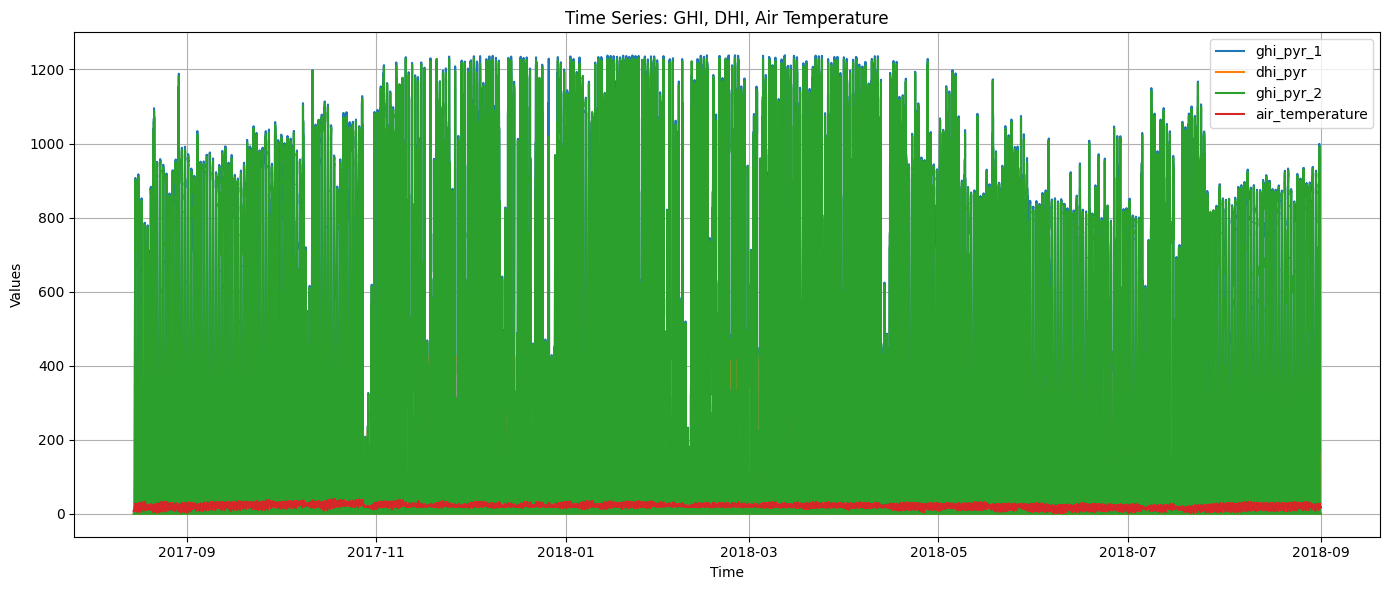

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned data
df_clean = pd.read_csv('data/zambia_clean.csv', low_memory=False)

# Try to find a timestamp-like column
possible_time_cols = [col for col in df_clean.columns if 'time' in col.lower() or 'date' in col.lower()]

if possible_time_cols:
    # Use the first timestamp-like column
    time_col = possible_time_cols[0]
    df_clean[time_col] = pd.to_datetime(df_clean[time_col], errors='coerce')
else:
    # If no timestamp column, create a synthetic datetime index
    df_clean['timestamp'] = pd.date_range(start='2020-01-01', periods=len(df_clean), freq='H')
    time_col = 'timestamp'

# Plotting selected variables over time
plt.figure(figsize=(14, 6))
for col in ['ghi_pyr_1', 'dhi_pyr', 'ghi_pyr_2', 'air_temperature']:
    if col in df_clean.columns:
        plt.plot(df_clean[time_col], df_clean[col], label=col)

plt.legend()
plt.title('Time Series: GHI, DHI, Air Temperature')
plt.xlabel('Time')
plt.ylabel('Values')
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned dataset
df_clean = pd.read_csv('data/zambia_clean.csv', low_memory=False)

# Handle missing values in sensor_cleaning, then convert to int
df_clean['sensor_cleaning'] = df_clean['sensor_cleaning'].fillna(0).astype(int)

# Ensure mod_a and mod_b exist and are numeric
if 'mod_a' in df_clean.columns and 'mod_b' in df_clean.columns:
    df_clean['mod_a'] = pd.to_numeric(df_clean['mod_a'], errors='coerce')
    df_clean['mod_b'] = pd.to_numeric(df_clean['mod_b'], errors='coerce')

    # Group by sensor_cleaning and calculate average
    mod_avg = df_clean.groupby('sensor_cleaning')[['mod_a', 'mod_b']].mean()

    # Plotting
    mod_avg.plot(kind='bar', title='Effect of Cleaning on ModA and ModB')
    plt.xlabel('Cleaning Flag (0 = Dirty, 1 = Cleaned)')
    plt.ylabel('Average Irradiance')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("mod_a or mod_b column is missing.")

mod_a or mod_b column is missing.


In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your cleaned data
df_clean = pd.read_csv('zambia.csv', low_memory=False)

# Print columns to see what exactly is in your DataFrame
print("Columns in DataFrame:", df_clean.columns.tolist())

# Define columns based on actual column names (replace these if needed)
corr_cols = ['ghi', 'dni', 'dhi', 'mod_a', 'mod_b']

# Check which of the desired columns are actually present
available_cols = [col for col in corr_cols if col in df_clean.columns]
print("Available columns for correlation:", available_cols)

# Proceed only if columns exist
if available_cols:
    df_clean[available_cols] = df_clean[available_cols].apply(pd.to_numeric, errors='coerce')
    df_corr = df_clean[available_cols].dropna()

    plt.figure(figsize=(8, 6))
    sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f", square=True)
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("None of the specified columns exist in the DataFrame.")

Columns in DataFrame: ['time', 'dhi_pyr', 'ghi_pyr_1', 'ghi_pyr_2', 'air_temperature', 'relative_humidity', 'barometric_pressure', 'precipitation', 'wind_speed', 'wind_from_direction', 'gti_clean', 'gti_soil', 'sensor_cleaning', 'comments']
Available columns for correlation: []
None of the specified columns exist in the DataFrame.


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df_clean = pd.read_csv('zambia.csv', low_memory=False)

# Print column names to verify what you have
print("Columns available:", df_clean.columns.tolist())

# Example: Replace these with the actual column names from your print output
pairplot_vars = ['ws', 'ws_gust', 'wd', 'ghi']  # <-- update these names accordingly

# Filter only columns that exist in df_clean
pairplot_vars = [col for col in pairplot_vars if col in df_clean.columns]

if pairplot_vars:
    sns.pairplot(df_clean, vars=pairplot_vars, diag_kind='kde')
    plt.suptitle("Scatter Relationships: Wind vs GHI", y=1.02)
    plt.show()
else:
    print("None of the pairplot variables exist in the DataFrame.")

# For scatterplot
if 'rh' in df_clean.columns and 'air_temperature' in df_clean.columns:
    sns.scatterplot(data=df_clean, x='rh', y='air_temperature')
    plt.title("RH vs Air Temperature")
    plt.grid(True)
    plt.show()
else:
    print("Columns 'rh' or 'air_temperature' not found in DataFrame.")

Columns available: ['time', 'dhi_pyr', 'ghi_pyr_1', 'ghi_pyr_2', 'air_temperature', 'relative_humidity', 'barometric_pressure', 'precipitation', 'wind_speed', 'wind_from_direction', 'gti_clean', 'gti_soil', 'sensor_cleaning', 'comments']
None of the pairplot variables exist in the DataFrame.
Columns 'rh' or 'air_temperature' not found in DataFrame.


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_clean is already loaded, if not, load it here:
# df_clean = pd.read_csv('zambia.csv', low_memory=False)

# Step 1: Check columns available
print("Columns in df_clean:", df_clean.columns.tolist())

# Step 2: Define possible column names for wind direction and wind speed
possible_wd_cols = ['wd', 'wind_direction', 'wind_dir', 'direction']
possible_ws_cols = ['ws', 'wind_speed', 'wind_spd']

# Step 3: Find the actual column names in your DataFrame
wd_col = next((col for col in possible_wd_cols if col in df_clean.columns), None)
ws_col = next((col for col in possible_ws_cols if col in df_clean.columns), None)

if wd_col is None or ws_col is None:
    print(f"Missing columns: wind direction column found? {wd_col}, wind speed column found? {ws_col}")
    print("Please check your DataFrame columns and update the column names accordingly.")
else:
    # Convert wind direction degrees to radians
    df_clean['wd_rad'] = np.deg2rad(df_clean[wd_col])

    # Bin wind directions into 8 bins (0° to 360°, every 45°)
    df_clean['wd_bin'] = pd.cut(df_clean[wd_col], bins=np.arange(0, 361, 45), labels=False, right=False)

    # Calculate average wind speed per bin
    wind_avg = df_clean.groupby('wd_bin')[ws_col].mean().fillna(0)

    # Create angles for each bin in radians
    angles = np.linspace(0, 2 * np.pi, len(wind_avg), endpoint=False)

    # Plot the wind rose approximation
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, polar=True)
    bars = ax.bar(angles, wind_avg, width=0.5, bottom=0.0)

    ax.set_theta_zero_location("N")  # 0 degrees at the top (North)
    ax.set_theta_direction(-1)       # Clockwise direction
    ax.set_title("Wind Rose Approximation", va='bottom')

    plt.show()

Columns in df_clean: ['time', 'dhi_pyr', 'ghi_pyr_1', 'ghi_pyr_2', 'air_temperature', 'relative_humidity', 'barometric_pressure', 'precipitation', 'wind_speed', 'wind_from_direction', 'gti_clean', 'gti_soil', 'sensor_cleaning', 'comments']
Missing columns: wind direction column found? None, wind speed column found? wind_speed
Please check your DataFrame columns and update the column names accordingly.


In [17]:
import matplotlib.pyplot as plt

# Print columns to see actual names
print("Columns in df_clean:", df_clean.columns.tolist())

# Define expected columns
cols_to_plot = ['ghi', 'ws']

# Find which columns exist
existing_cols = [col for col in cols_to_plot if col in df_clean.columns]

if len(existing_cols) == 0:
    print(f"None of the columns {cols_to_plot} were found in df_clean. Please check your column names.")
else:
    # Plot histograms only for existing columns
    df_clean[existing_cols].hist(bins=30, figsize=(5 * len(existing_cols), 4), layout=(1, len(existing_cols)))
    plt.suptitle("Distributions: " + ", ".join(existing_cols))
    plt.show()

Columns in df_clean: ['time', 'dhi_pyr', 'ghi_pyr_1', 'ghi_pyr_2', 'air_temperature', 'relative_humidity', 'barometric_pressure', 'precipitation', 'wind_speed', 'wind_from_direction', 'gti_clean', 'gti_soil', 'sensor_cleaning', 'comments']
None of the columns ['ghi', 'ws'] were found in df_clean. Please check your column names.


In [19]:
import plotly.express as px

fig = px.scatter(
    df_clean,
    x='ghi_pyr_1',               # replaced 'ghi' with 'ghi_pyr_1'
    y='air_temperature',
    size='relative_humidity',    # replaced 'rh' with 'relative_humidity'
    color='barometric_pressure', # replaced 'bp' with 'barometric_pressure'
    title='GHI vs Tamb (Bubble = RH, Color = BP)',
    labels={'ghi_pyr_1': 'GHI', 'air_temperature': 'Tamb'}
)
fig.show()


ValueError: 
    Invalid element(s) received for the 'size' property of scattergl.marker
        Invalid elements include: [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

    The 'size' property is a number and may be specified as:
      - An int or float in the interval [0, inf]
      - A tuple, list, or one-dimensional numpy array of the above